# Lab Task 2: Custom Blurring Filters

## Import Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Load Image

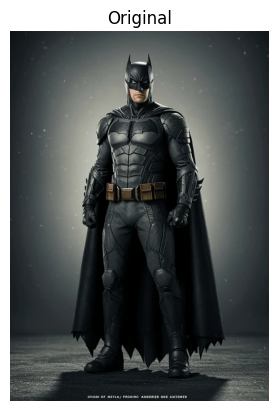

In [2]:
img_bgr = cv2.imread('../CVLab02/assets/batman.jpg')
img     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img); plt.title('Original'); plt.axis('off'); plt.show()

## Gaussian Blur

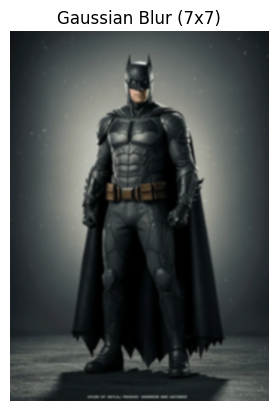

In [3]:
gauss = cv2.GaussianBlur(img, (7, 7), 0)

plt.imshow(gauss); plt.title('Gaussian Blur (7x7)'); plt.axis('off'); plt.show()

## Median Blur

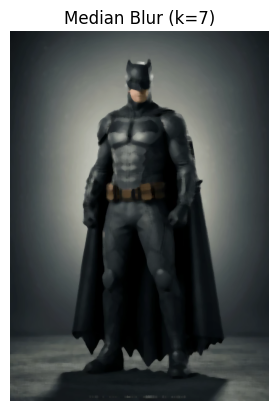

In [4]:
median = cv2.medianBlur(img, 7)

plt.imshow(median); plt.title('Median Blur (k=7)'); plt.axis('off'); plt.show()

## Custom Averaging Filter

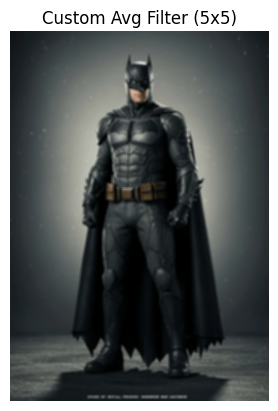

In [5]:
# 5x5 averaging kernel — each pixel becomes the mean of its 5x5 neighbourhood
kernel_5 = np.ones((5, 5), np.float32) / 25
custom_5  = cv2.filter2D(img, -1, kernel_5)

plt.imshow(custom_5); plt.title('Custom Avg Filter (5x5)'); plt.axis('off'); plt.show()

## Different Kernel Sizes

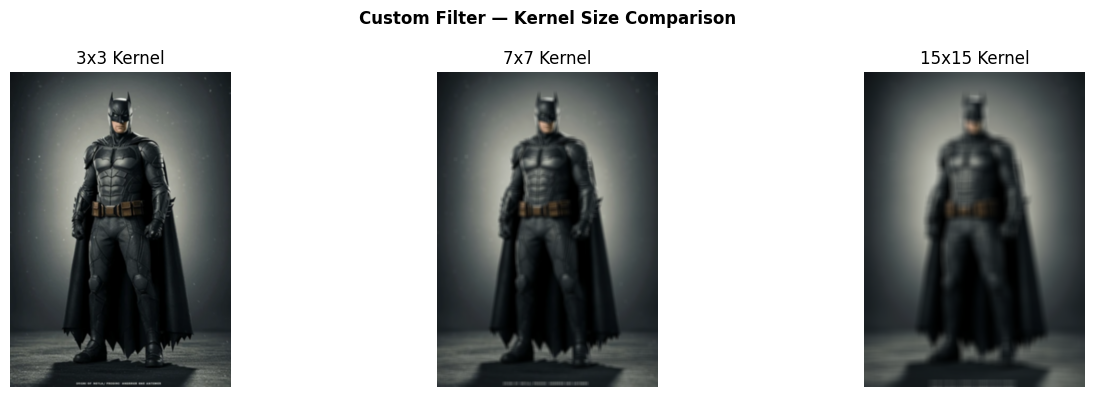

In [6]:
sizes = [3, 7, 15]
results = [cv2.filter2D(img, -1, np.ones((k, k), np.float32) / k**2) for k in sizes]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Custom Filter — Kernel Size Comparison', fontweight='bold')
for ax, res, k in zip(axes, results, sizes):
    ax.imshow(res); ax.set_title(f'{k}x{k} Kernel'); ax.axis('off')
plt.tight_layout(); plt.show()

## Custom Shaped Kernels

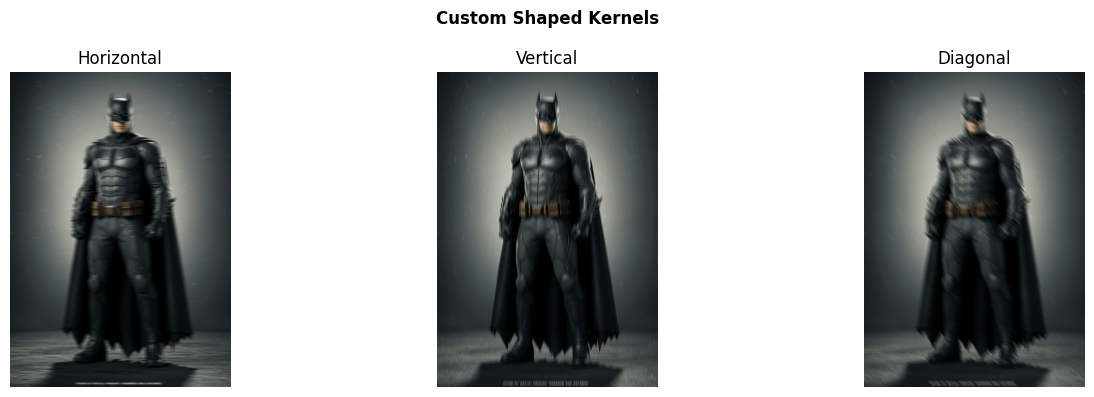

In [7]:
# Horizontal motion blur — averages only along a horizontal strip
kernel_h = np.zeros((9, 9), np.float32)
kernel_h[4, :] = 1.0 / 9

# Vertical motion blur — averages only along a vertical strip
kernel_v = np.zeros((9, 9), np.float32)
kernel_v[:, 4] = 1.0 / 9

# Diagonal motion blur
kernel_d = np.eye(9, dtype=np.float32) / 9

blur_h = cv2.filter2D(img, -1, kernel_h)
blur_v = cv2.filter2D(img, -1, kernel_v)
blur_d = cv2.filter2D(img, -1, kernel_d)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Custom Shaped Kernels', fontweight='bold')
for ax, res, t in zip(axes, [blur_h, blur_v, blur_d], ['Horizontal', 'Vertical', 'Diagonal']):
    ax.imshow(res); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

## Comparative Analysis

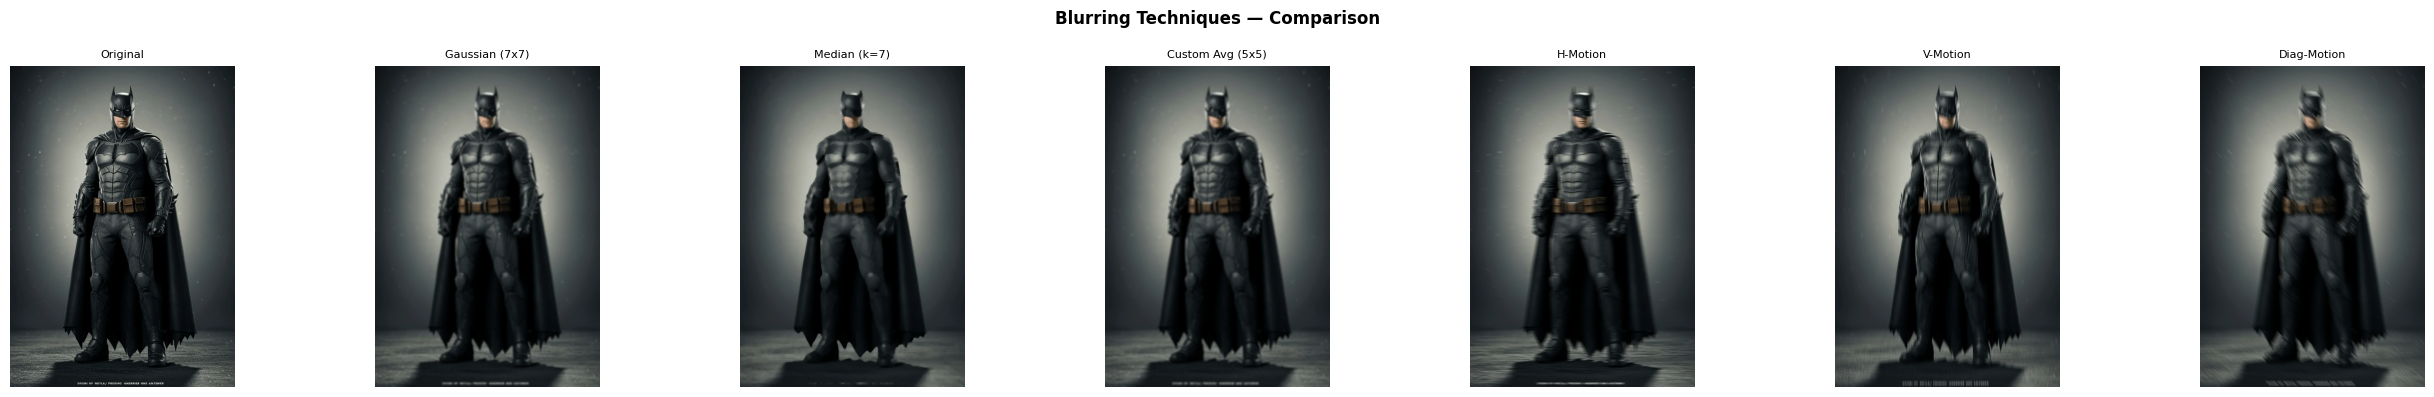

In [8]:
all_imgs   = [img,   gauss,            median,         custom_5,            blur_h,       blur_v,     blur_d]
all_labels = ['Original', 'Gaussian (7x7)', 'Median (k=7)', 'Custom Avg (5x5)', 'H-Motion', 'V-Motion', 'Diag-Motion']

fig, axes = plt.subplots(1, 7, figsize=(26, 4))
fig.suptitle('Blurring Techniques — Comparison', fontweight='bold')
for ax, im, lbl in zip(axes, all_imgs, all_labels):
    ax.imshow(im); ax.set_title(lbl, fontsize=8); ax.axis('off')
plt.tight_layout(); plt.show()